# Business Case

## Title


# Goal to showcase


## Step 1: Problem definition
### Business Need


### Pain Point


### Objective


### Expected Outcome



# Step 2: Data Collection

TEXT



In [44]:
import pandas as pd
import re

In [29]:
file_path = 'Data_labels.xlsx'

df = pd.read_excel(file_path)

In [30]:
df.shape

(150054, 15)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150054 entries, 0 to 150053
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idstore             150054 non-null  int64         
 1   sku                 150054 non-null  int64         
 2   brand               150054 non-null  object        
 3   oldpvp              150032 non-null  object        
 4   new_pvp (discount)  150026 non-null  object        
 5   labelqty            150054 non-null  int64         
 6   weight (g)          150050 non-null  object        
 7   Payment_method      150054 non-null  object        
 8   Margin (%)          150054 non-null  int64         
 9   Profit (€)          150054 non-null  float64       
 10  perc_expiring_sku   149929 non-null  float64       
 11  expiring_date       150054 non-null  object        
 12  labelling_date      150054 non-null  datetime64[ns]
 13  sell_date           80511 non

In [32]:
df = df.convert_dtypes()

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150054 entries, 0 to 150053
Data columns (total 15 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   idstore             150054 non-null  Int64         
 1   sku                 150054 non-null  Int64         
 2   brand               150054 non-null  string        
 3   oldpvp              150032 non-null  object        
 4   new_pvp (discount)  150026 non-null  string        
 5   labelqty            150054 non-null  Int64         
 6   weight (g)          150050 non-null  object        
 7   Payment_method      150054 non-null  string        
 8   Margin (%)          150054 non-null  Int64         
 9   Profit (€)          150054 non-null  Float64       
 10  perc_expiring_sku   149929 non-null  Float64       
 11  expiring_date       150054 non-null  string        
 12  labelling_date      150054 non-null  datetime64[ns]
 13  sell_date           80511 non

In [34]:
df.head()

,idstore,sku,brand,oldpvp,new_pvp (discount),labelqty,weight (g),Payment_method,Margin (%),Profit (€),perc_expiring_sku,expiring_date,labelling_date,sell_date,sold
0,1,1,Marca 1,4.22,2.11 (0.50),1,260,Card,16,0.3376,0.01005,03/10/2021,2021-10-01,2021-10-02,1
1,1,1,Marca 1,3.96,1.98 (0.50),1,260,,16,0.3168,0.005025,02/10/2021,2021-10-01,NaT,0
2,1,1,Marca 1,4.74,2.37 (0.50),1,260,Cash,16,0.3792,0.01005,03/10/2021,2021-10-01,2021-10-03,1
3,1,1,Marca 1,4.2,2.1 (0.50),1,260,Card,16,0.336,0.01005,03/10/2021,2021-10-01,2021-10-02,1
4,1,1,Marca 1,4.62,2.31 (0.50),1,260,Cash,16,0.3696,0.01005,03/10/2021,2021-10-01,2021-10-03,<NA>


## 2.1 Data Cleaning, Transformation and Exploring


A ideia é percorrer cada variável e fazer o seu estudo individual com uma caracterização do atributo em termos de tipo de dado (qualitativio, quantitativo...), valores distintos e intervalos existentes; transformações a ocorrer para garantir qualidade na utilização da variável para posterior consumo no ciclo de entrega.

# 2.1 Features Analysis - Dataset Labels

## idstore

Esta variável quantitativa discreta representa o identificador da loja.

Temos X lojas distintas.

Não existem valores ausentes.

O formato é numérico e assumido como inteiro. Não há necessidade de limpeza, tratamento.

## sku

Esta variável quantitativa discreta representa o identificador do produto.

Temos X produtos distintos.

Não existem valores ausentes.

O formato é numérico e assumido como inteiro. Não há necessidade de limpeza, tratamento.

## brand

In [43]:
df['brand'].sample(20)

40798      Marca  2
2567        marca 2
23546       Marca 2
56086      marca 28
126901    Marca  15
15357       Marca 2
119401    Marca   2
137683      marca 2
35012       marca 2
116278      Marca 7
19678      marca  7
76134      Marca 15
22974      marca  2
138245      Marca 2
128935     Marca 16
128476      marca 2
84393        Marca2
40224       marca 2
124245      Marca21
84631       marca 2
Name: brand, dtype: string

In [41]:
df['brand'].isnull().sum()

np.int64(0)

Esta variável qualitativa categórica representa a classificação da marca do SKU em questão.

Temos X marcas distintas.

Não existem valores ausentes.

O formato é texto não unformizado. Contém 

In [ ]:
def clean_brand(brand):
    if pd.isna(brand):
        return brand
    # 1. Uppercase
    brand = brand.upper()
    # 2. Remover espaços extras
    brand = " ".join(brand.split())
    # 3. Garantir espaço entre letras e números (MARCA21 -> MARCA 21)
    brand = re.sub(r'([A-Z])(\d+)', r'\1 \2', brand)
    # 4. Capitalizar para "Marca X"
    brand = brand.title()  
    
    return brand

In [48]:
df['brand'] = df['brand'].apply(clean_brand)
df['brand'].unique()

array(['Marca 1', 'Marca 2', 'Marca 3', 'Marca 4', 'Marca 5', 'Marca 6',
       'Marca 7', 'Marca 8', 'Marca 9', 'Marca 10', 'Marca 11',
       'Marca 12', 'Marca 13', 'Marca 14', 'Marca 15', 'Marca 16',
       'Marca 17', 'Marca 18', 'Marca 19', 'Marca 20', 'Marca 21',
       'Marca 22', 'Marca 23', 'Marca 24', 'Marca 25', 'Marca 26',
       'Marca 27', 'Marca 28', 'Marca 29', 'Marca 30', 'Marca 31',
       'Marca 32', 'Marca 33', 'Marca 34', 'Marca 35', 'Marca 36',
       'Marca 37', 'Marca 38', 'Marca 39', 'Marca 40', 'Marca 41',
       'Marca 42'], dtype=object)

In [50]:
def resumo_categorica(df, col):
    total = len(df)
    vc = df[col].value_counts(dropna=False)

    out = (vc.rename('abs')
             .reset_index()
             .rename(columns={'index': col})
             .sort_values('abs', ascending=False)
             .reset_index(drop=True))
    out['rel_%']  = (out['abs'] / total * 100).round(2)
    out['acum_%'] = out['rel_%'].cumsum().round(2)

    # Marcas que cobrem ~80% das ocorrências
    cutoff_idx = (out['acum_%'] >= 80).idxmax()  # primeiro a atingir 80%
    marcas_80 = out.loc[:cutoff_idx, col].tolist()

    return out, marcas_80

brand_summary, marcas_top80 = resumo_categorica(df, 'brand')


# ver as marcas que cobrem ~80% das ocorrências
print(marcas_top80)
# ver primeiras linhas
brand_summary.head(20)


['Marca 2', 'Marca 7']


,brand,abs,rel_%,acum_%
0,Marca 2,106163,70.75,70.75
1,Marca 7,15428,10.28,81.03
2,Marca 15,12543,8.36,89.39
3,Marca 5,5418,3.61,93.00
4,Marca 12,1760,1.17,94.17
5,Marca 25,1279,0.85,95.02
6,Marca 9,1126,0.75,95.77
7,Marca 3,880,0.59,96.36
8,Marca 33,846,0.56,96.92
9,Marca 28,725,0.48,97.40


In [ ]:
def plot_hist_categorica(summary_df, col, top_n=20):
    data = summary_df.head(top_n)
    plt.figure()
    plt.bar(data[col], data['abs'])
    plt.xticks(rotation=90)
    plt.ylabel('Frequência')
    plt.title(f'Distribuição de {col} (Top {top_n})')
    plt.tight_layout()
    plt.show()

plot_hist_categorica(brand_summary, 'brand', top_n=20)


## oldpvp

## new_pvp (discount)

## weight (g)

## Payment_method

## Margin (%)

## Profit (€)

## perc_expiring_sku

## expiring_date

## labelling_date

## sell_date

## sold (target)

In [35]:
df.isnull().sum().sum()

np.int64(69836)

In [36]:
df.isnull().sum()

idstore                   0
sku                       0
brand                     0
oldpvp                   22
new_pvp (discount)       28
labelqty                  0
weight (g)                4
Payment_method            0
Margin (%)                0
Profit (€)                0
perc_expiring_sku       125
expiring_date             0
labelling_date            0
sell_date             69543
sold                    114
dtype: int64

In [37]:
(df.isnull().mean() * 100).round(2)

idstore                0.00
sku                    0.00
brand                  0.00
oldpvp                 0.01
new_pvp (discount)     0.02
labelqty               0.00
weight (g)             0.00
Payment_method         0.00
Margin (%)             0.00
Profit (€)             0.00
perc_expiring_sku      0.08
expiring_date          0.00
labelling_date         0.00
sell_date             46.35
sold                   0.08
dtype: float64

In [38]:
df = df.dropna(subset=['discount_level','product_category'])

KeyError: ['discount_level', 'product_category']

In [ ]:
(df.isnull().mean() * 100).round(2)

base_price               3.01
product_category         0.00
customer_segment         0.00
is_peak_season           0.00
time_on_market_days      0.00
units_in_stock           0.00
marketing_spend_level    4.00
units_sold               0.00
revenue                  0.00
discount_level           0.00
dtype: float64

In [ ]:
df.describe()

,base_price,is_peak_season,time_on_market_days,units_in_stock,marketing_spend_level,units_sold,revenue
count,876871.000000,904103.000000,904103.000000,904103.000000,867938.000000,904103.000000,904103.000000
mean,71.639860,0.199797,40.002312,2024.777891,50.003673,250.611101,17620.787494
std,33.778287,0.399848,6.325175,999.272132,22.370906,83.530893,11913.938495
min,4.690000,0.000000,13.000000,163.000000,0.110000,5.000000,89.860000
25%,51.640000,0.000000,36.000000,1290.000000,32.620000,185.000000,8085.180000
50%,68.783000,0.000000,40.000000,1808.000000,50.040000,255.000000,15133.620000
75%,96.310000,0.000000,44.000000,2531.000000,67.320000,315.000000,24220.200000
max,210.199000,1.000000,78.000000,5000.000000,99.910000,495.000000,81889.730000


In [ ]:
#df = df.dropna(subset=['base_price','marketing_spend_level'])

In [ ]:
(df.isnull().mean() * 100).round(2)

base_price               0.0
product_category         0.0
customer_segment         0.0
is_peak_season           0.0
time_on_market_days      0.0
units_in_stock           0.0
marketing_spend_level    0.0
units_sold               0.0
revenue                  0.0
discount_level           0.0
dtype: float64

### 2.1.2 Checking for duplicates

In [ ]:
df.duplicated().sum()

np.int64(62382)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.duplicated().sum()

np.int64(0)

Now the dataset is cleaned and we can advanced further for EDA Step and afterwards to the transformations of variables we see fit for better model performance.

# Step: 3 EDA (exploratory data analysis)

After EDA is done, it's possible to decide which variables to include (the ones that can add value to explaining output) and be part of the dataset to feed data to the model afterwards!


In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 3.1 Numeric variables analysis

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()  # selecting only the cols with numeric data type
df[numeric_cols].describe().T # stats about the cols, transposed view

,count,mean,std,min,25%,50%,75%,max
idstore,150054.0,139.234242,87.056044,1.0,59.0,135.0,212.0,332.0
sku,150054.0,163.699422,87.247006,1.0,99.0,160.0,236.0,319.0
labelqty,150054.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Margin (%),150054.0,15.82495,3.303568,10.0,13.0,17.0,19.0,20.0
Profit (€),150054.0,0.175131,0.268439,0.034,0.1245,0.1529,0.2224,99.9
perc_expiring_sku,149929.0,0.385245,0.223626,0.0,0.2,0.333333,0.666667,2.0
sold,149940.0,0.536568,0.498663,0.0,0.0,1.0,1.0,1.0


Plotting visuals can help to understand our distribution in each feature. Therefore ahistogram and also a box plot will help in this matter;

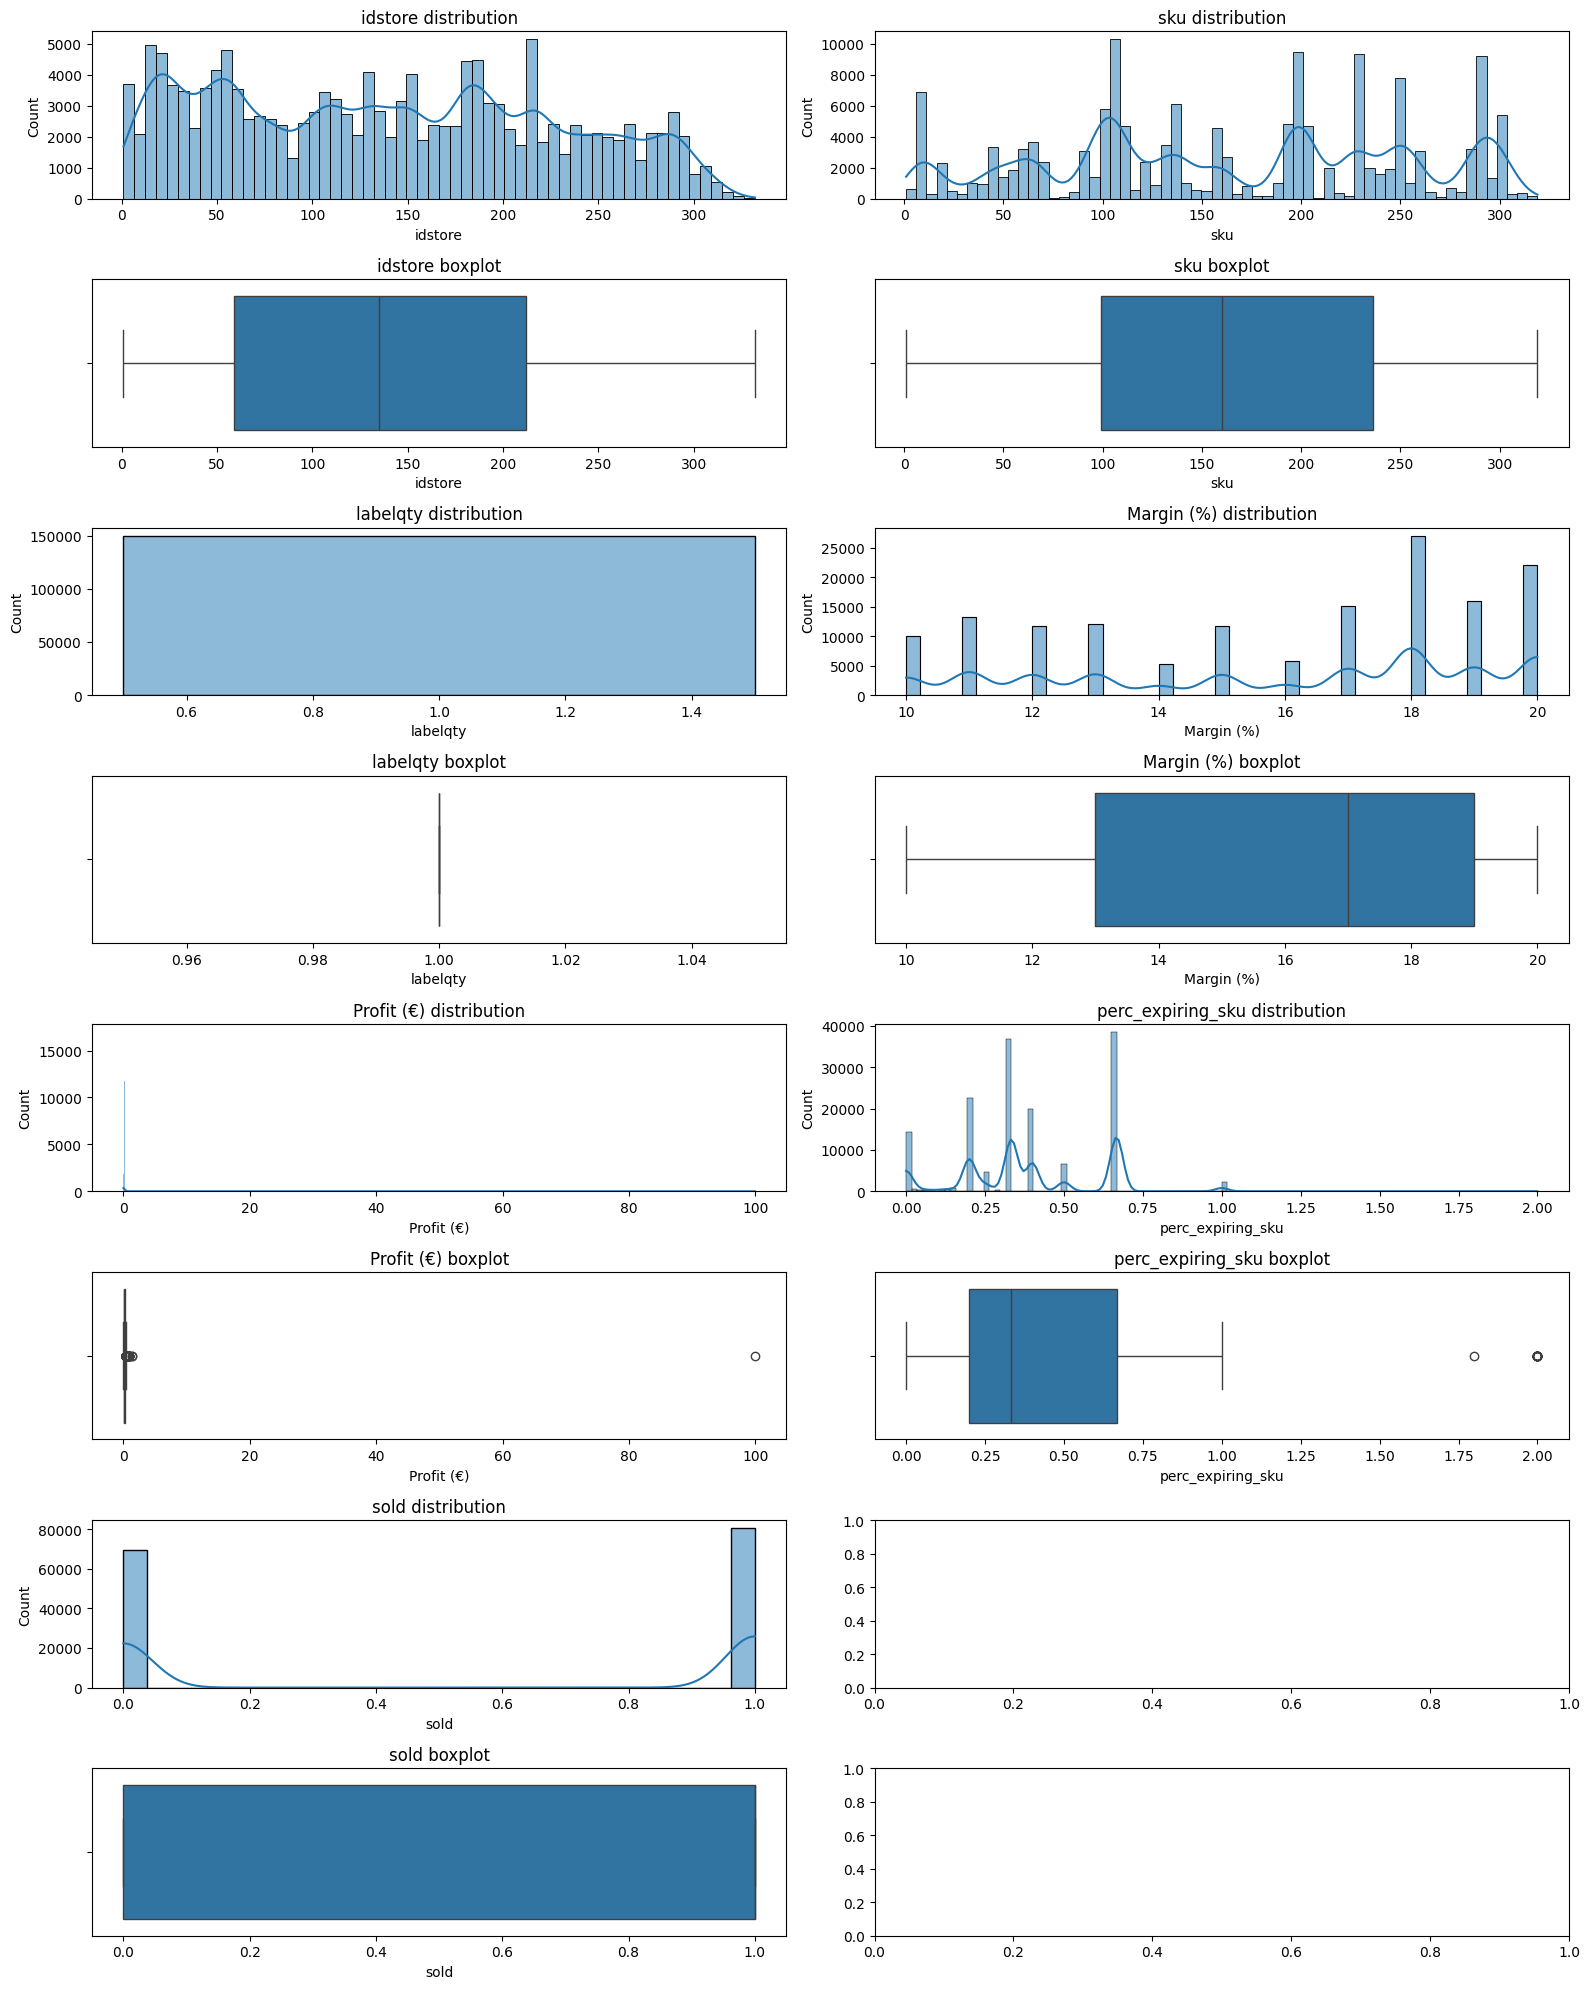

In [ ]:
from math import ceil

cols_per_row = 2
num_vars = len(numeric_cols)
rows = ceil(num_vars / cols_per_row) * 2 

fig, axes = plt.subplots(rows, cols_per_row, figsize=(cols_per_row * 8, rows * 2.5)) # creating the figure & axes matrix; figsize is about dimensions to give space for charts
axes = axes.flatten()  # to return a 1D array so we iterate over, axes = [0,1,2,3,4,5,6,7] 

for idx, col in enumerate(numeric_cols):
    # to calculate the coordinates
    row_offset = (idx // cols_per_row) * cols_per_row * 2 
    col_offset = idx % cols_per_row # use a sequence where since cols per row is 2, its a even number, so when iterating, position in 0 or 1 col pos

    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[row_offset + col_offset])
    axes[row_offset + col_offset].set_title(f"{col} distribution")

    # Boxplot 
    sns.boxplot(x=df[col], ax=axes[row_offset + cols_per_row + col_offset], orient='h')
    axes[row_offset + cols_per_row + col_offset].set_title(f"{col} boxplot")

plt.tight_layout()
plt.show()

In [ ]:
df = df.dropna(subset=['labelqty'])

#### 3.1.1 Comments on features distribution (example)

##### 3.1.1.1 Variable and comments

In [ ]:
q1 = df['base_price'].quantile(0.25)
median = df['base_price'].quantile(0.50)
q3 = df['base_price'].quantile(0.75)
print(q1)
print(q3)
iqr = q3-q1
print(iqr)

iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr
lower_whisker = q1 - 1.5 * iqr
print("Upper whisker (max non-outlier value):", upper_whisker.round(2))
print("Lower whisker (min non-outlier value):", lower_whisker.round(2))

51.66
96.327
44.667
Upper whisker (max non-outlier value): 163.33
Lower whisker (min non-outlier value): -15.34


In [ ]:
q1 = df['revenue'].quantile(0.25).round(2)
q3 = df['revenue'].quantile(0.75).round(2)
print(q1)
print(q3)
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr
lower_whisker = q1 - 1.5 * iqr
print("Upper whisker (max non-outlier value):", upper_whisker.round(2))
print("Lower whisker (min non-outlier value):", lower_whisker.round(2))

8096.04
24228.11
Upper whisker (max non-outlier value): 48426.22
Lower whisker (min non-outlier value): -16102.06


##### 3.1.1.2 Removing Outliers in 'units_in_stock'

Since the histogram reveals a noticeable spike at the highest price values — likely outliers — I decided to filter out those cases for illustration purposes only

In [ ]:
q1 = df['units_in_stock'].quantile(0.25).round(2)
q3 = df['units_in_stock'].quantile(0.75).round(2)
print(q1)
print(q3)
iqr = q3 - q1
upper_whisker = q3 + 1.5 * iqr
print("Upper whisker (max non-outlier value):", upper_whisker.round(2))

1290.0
2532.0
Upper whisker (max non-outlier value): 4395.0


In [ ]:
df_model = df[df['units_in_stock'] <= upper_whisker]

### 3.2 Categorical variables analysis

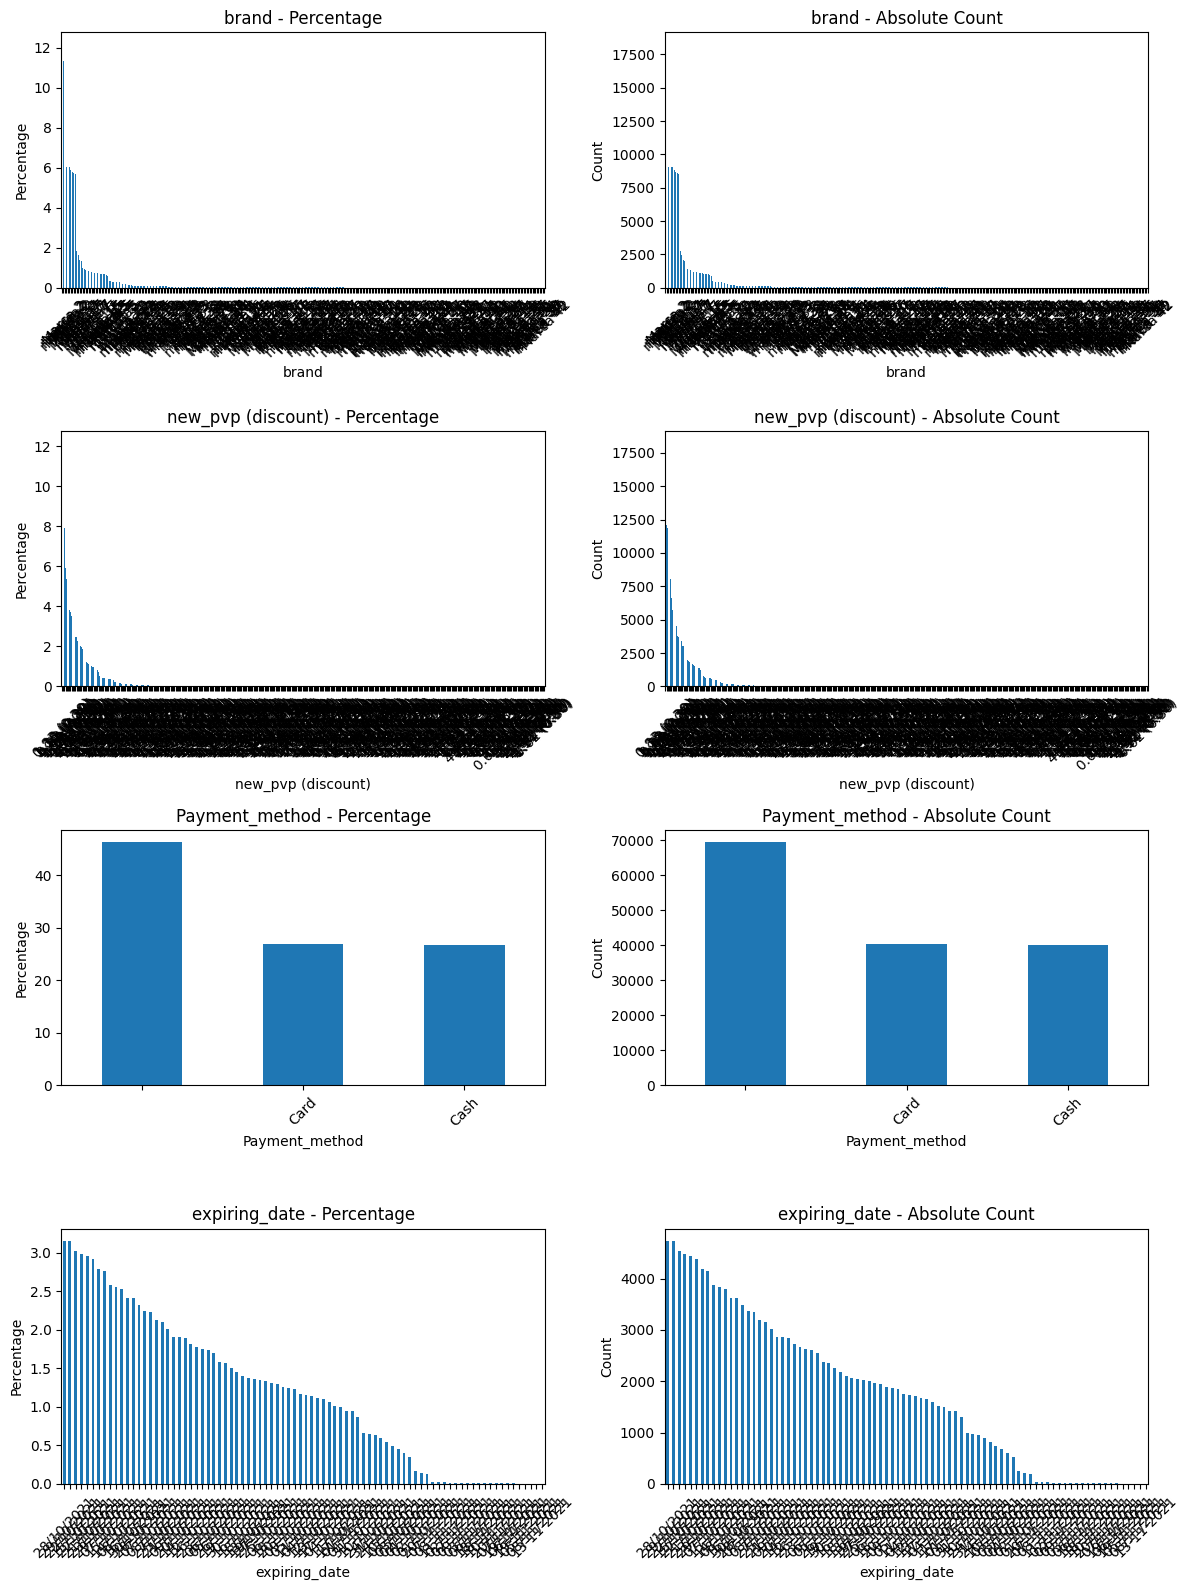

In [ ]:
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include='string').columns.tolist()

n_vars = len(categorical_cols)
fig, axes = plt.subplots(n_vars, 2, figsize=(12, 4 * n_vars))  

if n_vars == 1:
    axes = [axes]

for i, col in enumerate(categorical_cols):
    # Absolute counts
    df[col].value_counts().plot(kind='bar', ax=axes[i][1])
    axes[i][1].set_title(f"{col} - Absolute Count")
    axes[i][1].tick_params(axis='x', rotation=45)
    axes[i][1].set_ylabel("Count")

    # Percentages
    (df[col].value_counts(normalize=True) * 100).plot(kind='bar', ax=axes[i][0])
    axes[i][0].set_title(f"{col} - Percentage")
    axes[i][0].tick_params(axis='x', rotation=45)
    axes[i][0].set_ylabel("Percentage")

plt.tight_layout()
plt.show()

Distribution on categories by variables on % and absolute values; could help understand better the business step up for better interpretation of the model to be created.

## 3.3 Bivariate analysis

### 3.3.1 Correlation

Creation of a correlation Matrix can help us identify which variables are correlated between each other and avoid multicollinearity (important for model outcome); 
- plus their relationship of influence on the outcome variable - target revenue;
- also understand if business knowledge previoulsy gather is aligned with data and vice-versa;

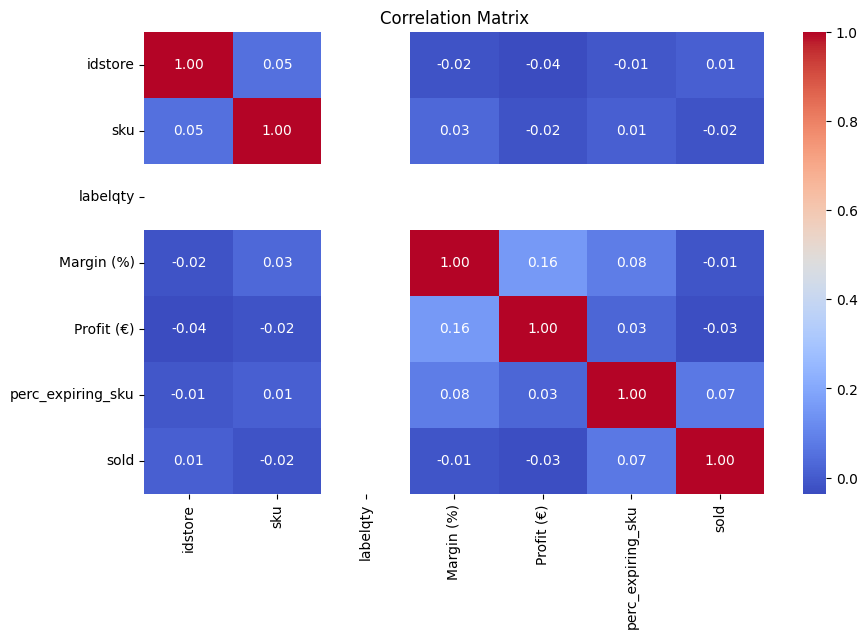

In [ ]:
plt.figure(figsize=(10, 6))
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

In [ ]:
if "sold" in df.columns:
    print("\nTop correlations with sold:")
    corr_series = df[numeric_cols].corr()['sold'].drop("sold")
    print(corr_series.sort_values(ascending=False))




Top correlations with sold:
perc_expiring_sku    0.071058
idstore              0.009083
Margin (%)          -0.011952
sku                 -0.019480
Profit (€)          -0.030703
labelqty                  NaN
Name: sold, dtype: float64


### 3.3.2 Sold vs Numeric Features

**Note:**
- This relationships are just to showcase a routine, they don't actual mean business truth 100%.

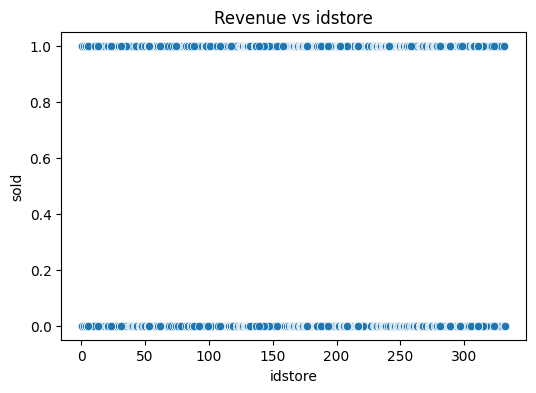

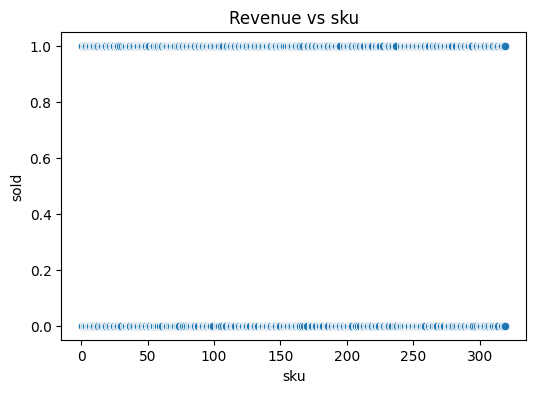

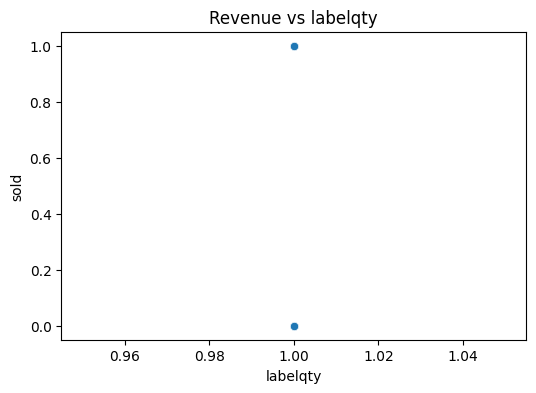

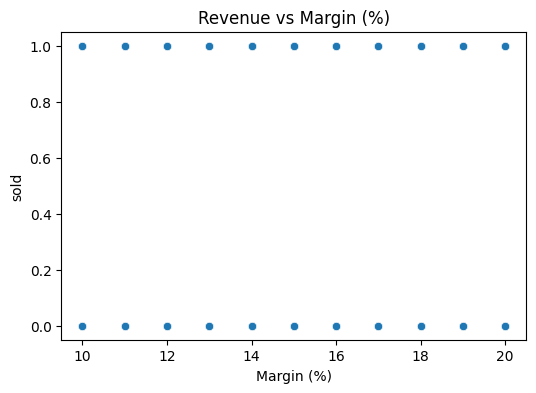

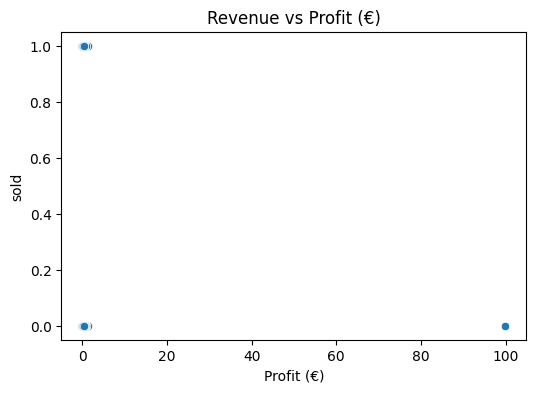

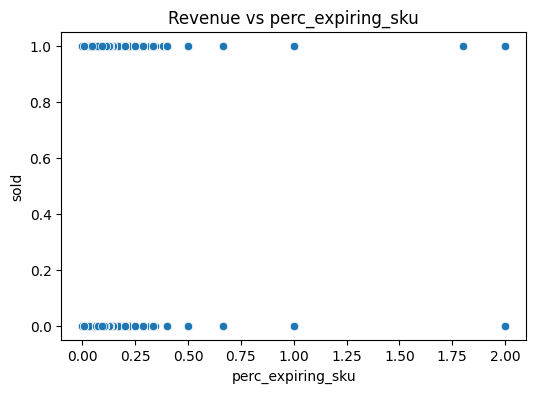

In [20]:
for col in numeric_cols:
    if col != "sold":
        plt.figure(figsize=(6, 4))
        sns.scatterplot(x=df[col], y=df["sold"])
        plt.title(f"Revenue vs {col}")
        plt.show()

### 3.3.3 Sold vs Categorical Features with boxPlots

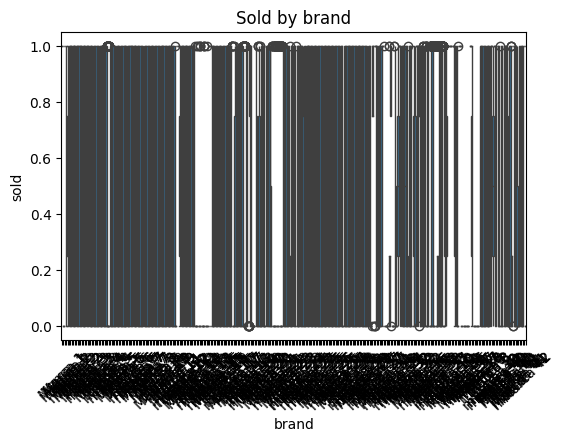

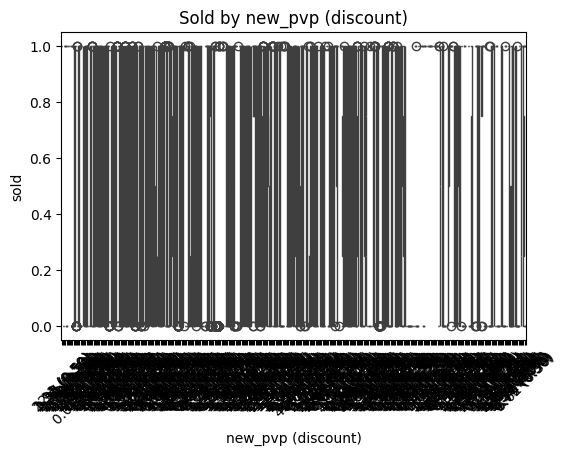

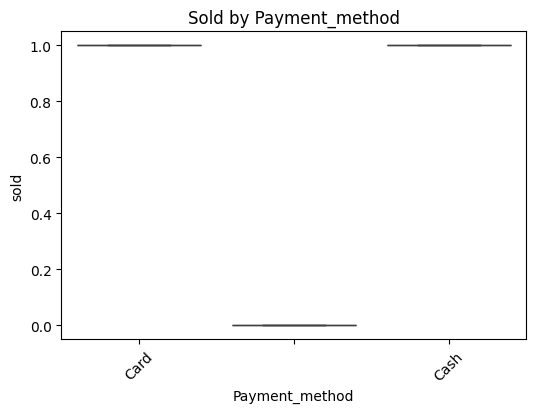

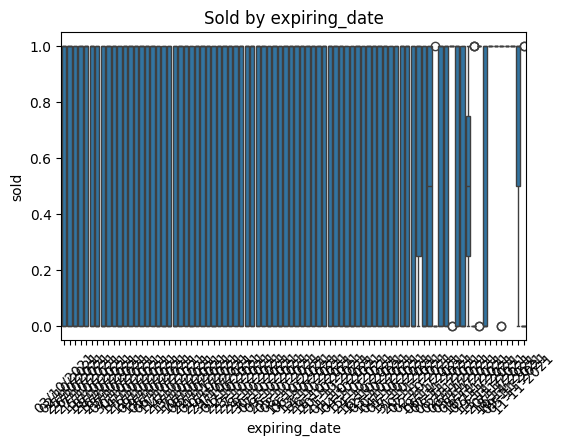

In [22]:
for col in categorical_cols:
    if "sold" in df.columns:
        plt.figure(figsize=(6, 4))
        sns.boxplot(x=col, y="sold", data=df)
        plt.title(f"Sold by {col}")
        plt.xticks(rotation=45)
        plt.show()

## 3.3.4 One-hot encoding for categorical variables

Since models don't understand this variables (text ones), we need to convert them into numerical format! By that we can include the in a linear equation input;

Each category of the variable becomes *a binary column* (1 if it applies, 0 if not)

Allows the model to treat each category independently!

So to levarage, we use them in the model to learn different effects of these categorical, seen as imoprtant previously;

In [33]:
df_encoded = pd.get_dummies(df_model, columns=["customer_segment", "product_category","discount_level"], drop_first=True).astype(int)

- drop_first will allow to avoid multicollinearity, basically when one variable can be reach through other (linear combination), we don't need to use it to avoid redundancy;
- this is at the basis of the linear multiple regression resolution, where the matrix of known data points needs to be invertible and therefore all cols linear independent, so a solution is reached for the system of linear equations to be determined...

In [34]:
df_encoded.head()

,base_price,is_peak_season,time_on_market_days,units_in_stock,marketing_spend_level,units_sold,revenue,customer_segment_Distributor,customer_segment_OEM,product_category_Energy IC,product_category_Microcontroller,product_category_Sensor,discount_level_high,discount_level_low,discount_level_medium
1,67,0,33,2592,50,259,15963,0,1,0,0,0,0,0,1
2,63,0,41,3385,39,244,14768,0,1,0,1,0,0,1,0
3,62,1,37,2036,30,320,20078,0,1,0,1,0,0,0,0
4,97,0,27,3345,37,239,22157,0,1,0,0,0,0,1,0
5,74,0,29,1294,81,321,20917,0,1,1,0,0,0,0,1


# Step 4: Creating the Model